# Класифікатор на основі TensorFlow

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
import pandas as pd
from tensorflow.keras.utils import to_categorical
from tensorflow import keras
from tensorflow.keras.backend import epsilon
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

from sklearn.metrics import confusion_matrix, multilabel_confusion_matrix
import seaborn as s
import os
import sys

In [2]:
image_height = 64
image_width = 64
batch_size = 32

Вантажимо датасет. Змінюємо шлях до зображень. Прибираємо не-зображення які потрапили до датасету. Енкодимо наші лейбли

In [3]:
cards = pd.read_csv('../cards/processed_cards.csv')


In [4]:
class HiddenPrints: # клас для того що б в output нічого не виводилось
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

In [5]:
cards['filepaths'] = cards['filepaths'].apply(lambda x: f'../cards/{x}')

In [6]:
cards.head()

,class index,filepaths,labels,card type,data set,suit,labels_encoded,type,type suit,final_label
0,0,../cards/train/ace of clubs/001.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,number
1,0,../cards/train/ace of clubs/002.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,number
2,0,../cards/train/ace of clubs/003.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,number
3,0,../cards/train/ace of clubs/004.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,number
4,0,../cards/train/ace of clubs/005.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,number


In [7]:
cards = cards[cards['filepaths'].str.endswith(('.jpg', '.jpeg', '.png'))]
cards['final_label'] = cards['final_label'].astype('category').cat.codes

cards['final_label2'] = cards['final_label']

from copy import deepcopy
cards2 = deepcopy(cards)

In [8]:
cards

,class index,filepaths,labels,card type,data set,suit,labels_encoded,type,type suit,final_label,final_label2
0,0,../cards/train/ace of clubs/001.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,2,2
1,0,../cards/train/ace of clubs/002.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,2,2
2,0,../cards/train/ace of clubs/003.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,2,2
3,0,../cards/train/ace of clubs/004.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,2,2
4,0,../cards/train/ace of clubs/005.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,2,2
...,...,...,...,...,...,...,...,...,...,...,...
7110,52,../cards/valid/two of spades/1.jpg,two of spades,two,valid,spades,52,number,number spades,2,2
7111,52,../cards/valid/two of spades/2.jpg,two of spades,two,valid,spades,52,number,number spades,2,2
7112,52,../cards/valid/two of spades/3.jpg,two of spades,two,valid,spades,52,number,number spades,2,2
7113,52,../cards/valid/two of spades/4.jpg,two of spades,two,valid,spades,52,number,number spades,2,2


In [9]:
cards = cards.sample(frac=1, random_state=42).reset_index(drop=True)
cards = cards.groupby('final_label')


Робимо процесинг зображень на вхід (читаємо, змінюємо розмір, нормалізовуємо) та створюємо датасет. Беремо по половині з кожного класу в попередньо згрупованому датасеті та перемішуємо їх аби уникнути дегенеративних моделей. Розмір зображень було зменшено в порівнянні з попередньою лабораторною через складність створення високоякісної GAN моделі.

Ділимо датасет на тренувальний та тестовий - рандомізуємо порядок та ділимо навпіл. Причини такого великого тестового набору залишаються ті ж що і в попередній лабораторній. Будуємо модель простого CNN класифікатора.



In [10]:


train_df = pd.concat([group[:len(group)//2] for _, group in cards])
test_df = pd.concat([group[len(group)//2:] for _, group in cards])
train_df['final_label'] = train_df['final_label2']
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df['final_label'] = test_df['final_label2']
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)
x = train_df['filepaths'].values
y = train_df['final_label'].values
num_classes = len(cards['final_label'].unique())

def process_input(file_path, y):
    x = tf.io.read_file(file_path)
    x = tf.image.decode_jpeg(x, channels=3)
    # Resize and normalize
    x = tf.image.resize(x, [image_height, image_width])
    x = 2*(tf.cast(x, tf.float32) / 255.0) - 1  # нормалізуємо до [-1, 1]
    return x, y

print(len(train_df))

train_df = tf.data.Dataset.from_tensor_slices((x, y))
train_df = train_df.map(process_input, num_parallel_calls=tf.data.AUTOTUNE)
train_df = train_df.batch(batch_size).prefetch(tf.data.AUTOTUNE)

3555


In [11]:
test_df = test_df[['filepaths', 'final_label']]

In [12]:
y

array([1, 2, 2, ..., 2, 3, 2], shape=(3555,), dtype=int8)

In [13]:
model = Sequential([
  layers.Rescaling(1./255, input_shape=(image_height, image_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dropout(0.3),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

C:\LData\LabsKPI13\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
train_df

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int8, name=None))>

In [15]:
model.compile(optimizer='adam',
              metrics=['accuracy'],
			  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True))
# без лосу неможливо зробити модельку

Тренуємо модель. Дивимось на результати

In [16]:
history = model.fit(train_df, epochs=8)

Epoch 1/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.8518 - loss: 0.6740
Epoch 2/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8543 - loss: 0.5681
Epoch 3/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8568 - loss: 0.4622
Epoch 4/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8588 - loss: 0.4258
Epoch 5/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8647 - loss: 0.4100
Epoch 6/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.8726 - loss: 0.3916
Epoch 7/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8805 - loss: 0.3681
Epoch 8/8
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8886 - loss: 0.3449


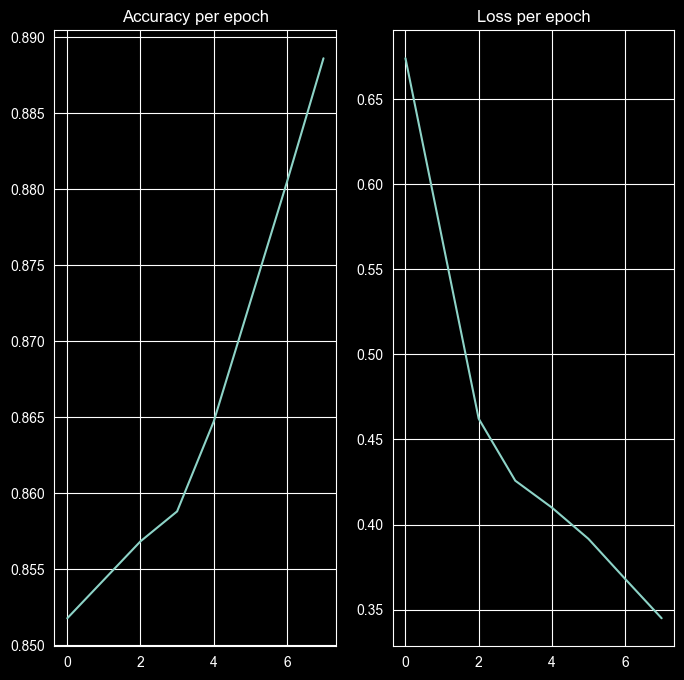

In [17]:
acc = history.history['accuracy']
loss = history.history['loss']

epochs_range = range(8)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.title("Accuracy per epoch")
plt.plot(epochs_range,acc)


plt.subplot(1, 2, 2)
plt.plot(epochs_range,loss)
plt.title("Loss per epoch")
plt.show()

In [18]:

x = test_df['filepaths'].values
y = test_df['final_label'].values
test_df = tf.data.Dataset.from_tensor_slices((x, y))
test_df = test_df.map(process_input, num_parallel_calls=tf.data.AUTOTUNE)
test_df = test_df.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [19]:
y_pred = model.predict(test_df)

112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


In [20]:
model.evaluate(test_df)

112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8797 - loss: 0.3813


[0.3812589645385742, 0.8797414898872375]

Будуємо матрицю невідповідності. Можна побачити що основна проблема - "false positive" домінуючого класу. Варто зауважити що тренування відбувається батчами і беручи більше 32 значень в батч (64+) домінуючий клас зробить модель виродженою (в 100% випадків буде надавати вхідним даним домінуючий клас). Також модель доволі часто затсрягає на 0.8543 точності (що є кількістю домінуючого класу в тренувальному датасеті, хоч модель що застрягла й не завжди є виродженою). Зберігаємо модель для подальшого використання

In [21]:
y_pred = model.predict(test_df)
y_pred = tf.argmax(y_pred, axis=1)
cm = tf.math.confusion_matrix(labels=y, predictions=y_pred)
print(cm)

112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
tf.Tensor(
[[   1   36   90   51    0]
 [   1   46   75   23    0]
 [   0    0 3019   18    0]
 [   1   14   87   65    0]
 [   0    2   30    0    0]], shape=(5, 5), dtype=int32)


In [22]:
from sklearn.metrics import f1_score
f1_per_class = f1_score(y, y_pred, average=None)
print('F1 по класам:')
for cls_id, f1 in enumerate(f1_per_class):
    print(f'  Клас {cls_id}: {f1:.4f}')

F1 по класам:
  Клас 0: 0.0110
  Клас 1: 0.3786
  Клас 2: 0.9527
  Клас 3: 0.4012
  Клас 4: 0.0000


Судячи по F1 по класам, модель так собі працює на не-домінуючих класах.

In [23]:
model.save('no-gan.keras')


## Тренування з додаванням згенерованих зображень

Додаємо зображення з папки `generated_images` до тренувального датасету. Кожна підпапка відповідає класу (jack, king, queen, xxx). Тренуємо модель з тією ж архітектурою.

In [25]:
temp_cards = pd.read_csv('../cards/processed_cards.csv')
label_names_sorted = sorted(temp_cards['final_label'].unique())
labels = {name: i for i, name in enumerate(label_names_sorted)}

generated_dir = 'generated_images'
gen_filepaths = []
gen_labels = []

for folder_name in os.listdir(generated_dir):
    folder_path = os.path.join(generated_dir, folder_name)
    if not os.path.isdir(folder_path):
        continue
    label = labels[folder_name]
    for img_file in os.listdir(folder_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            gen_filepaths.append(os.path.join(generated_dir, folder_name, img_file))
            gen_labels.append(label)

gen_df = pd.DataFrame({'filepaths': gen_filepaths, 'final_label': gen_labels})
print(gen_df['final_label'].value_counts().sort_index())

final_label
0    5
1    5
3    5
4    5
Name: count, dtype: int64


In [ ]:
original_train = cards2[cards2['data set'] == 'train'][['filepaths', 'final_label']].copy()
original_train = original_train.sample(frac=1, random_state=42).reset_index(drop=True)
original_train = original_train.groupby('final_label')
original_train = pd.concat([group[:len(group)//2] for _, group in original_train])

combined_df = pd.concat([original_train[['filepaths', 'final_label']], gen_df], ignore_index=True)
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

x_combined = combined_df['filepaths'].values
y_combined = combined_df['final_label'].values

train_df_gan = tf.data.Dataset.from_tensor_slices((x_combined, y_combined))
train_df_gan = train_df_gan.map(process_input, num_parallel_calls=tf.data.AUTOTUNE)
train_df_gan = train_df_gan.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [ ]:
model_gan = Sequential([
  layers.Rescaling(1./255, input_shape=(image_height, image_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dropout(0.3),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model_gan.compile(optimizer='adam',
              metrics=['accuracy'],
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True))

In [ ]:
history_gan = model_gan.fit(train_df_gan, epochs=8)

In [ ]:
acc_gan = history_gan.history['accuracy']
loss_gan = history_gan.history['loss']

epochs_range_gan = range(len(acc_gan))

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.title("Accuracy per epoch (з GAN)")
plt.plot(epochs_range_gan, acc_gan)

plt.subplot(1, 2, 2)
plt.plot(epochs_range_gan, loss_gan)
plt.title("Loss per epoch (з GAN)")
plt.show()

In [ ]:
model_gan.evaluate(test_df)

y_pred_gan = model_gan.predict(test_df)
y_pred_gan = tf.argmax(y_pred_gan, axis=1)
cm_gan = tf.math.confusion_matrix(labels=y, predictions=y_pred_gan)
print(cm_gan)

f1_per_class_gan = f1_score(y, y_pred_gan, average=None)
print('\nF1 по класам:')
for cls_id, f1 in enumerate(f1_per_class_gan):
    print(f'  Клас {cls_id}: {f1:.4f}')

In [ ]:
model_gan.save('with-gan.keras')